# Análisis A/B para optimización de ingresos en e-commerce

## Contexto

Una tienda online busca identificar oportunidades para aumentar sus ingresos. Para ello, el equipo de marketing ha definido varias hipótesis de crecimiento y ha realizado un experimento A/B para evaluar el impacto de una de las iniciativas propuestas.

## Objetivo

El análisis tiene dos objetivos principales:

* Priorizar las hipótesis de crecimiento mediante los frameworks **ICE y RICE**.
* Analizar los resultados del **test A/B** para determinar si existen diferencias significativas entre los grupos y recomendar una decisión de negocio.


## Resumen ejecutivo

Este proyecto analiza cómo una tienda online puede mejorar sus resultados mediante la priorización de iniciativas de crecimiento y la evaluación de un experimento A/B.

### Principales resultados

- **RICE modificó la priorización de las hipótesis** al incorporar el alcance de usuarios, situando la hipótesis 7 como la iniciativa con mayor prioridad.
- Se detectaron **58 usuarios presentes en ambos grupos**, que fueron excluidos para evitar contaminar el experimento.
- El grupo B obtuvo una **conversión aproximadamente 18.9% superior** después de eliminar valores atípicos.
- La diferencia en conversión fue **estadísticamente significativa** (`p-value = 0.00702`).
- No se encontraron diferencias significativas en el **tamaño promedio de pedido** (`p-value = 0.82203`).
- Un pedido excepcional de **19,920.4** estaba distorsionando inicialmente el comportamiento del grupo B.

### Decisión de negocio

**Detener el experimento y considerar al grupo B como la variante ganadora**, ya que mejora significativamente la conversión sin evidencia de una mejora real en el tamaño promedio de pedido.

## Datos y herramientas

### Datos

El análisis utiliza tres datasets proporcionados originalmente como parte de un ejercicio del programa de Data Analyst de TripleTen:

- `hypotheses_us.csv`: hipótesis de crecimiento con métricas de Reach, Impact, Confidence y Effort.
- `orders_us.csv`: información sobre pedidos, usuarios, fechas, ingresos y grupo experimental.
- `visits_us.csv`: número diario de visitas para los grupos A y B.

Los datasets originales no se redistribuyen públicamente en este repositorio.

### Herramientas

- **Python**
- **pandas** para preparación y análisis de datos
- **NumPy** para operaciones numéricas
- **Matplotlib** para visualización
- **SciPy** para pruebas estadísticas
- **Jupyter / Google Colab** para el desarrollo del análisis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

hypotheses = pd.read_csv('/content/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/content/orders_us.csv')
visits = pd.read_csv('/content/visits_us.csv')

## Revisión inicial de los datos

Se revisará la estructura, dimensiones y calidad básica de los datasets antes de comenzar el análisis.


In [ ]:
datasets = {
    'hypotheses': hypotheses,
    'orders': orders,
    'visits': visits
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print('Dimensiones:', df.shape)
    display(df.head())
    print('\nValores ausentes:')
    display(df.isna().sum())
    print('Duplicados:', df.duplicated().sum())


HYPOTHESES
Dimensiones: (9, 5)


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1



Valores ausentes:


,0
Hypothesis,0
Reach,0
Impact,0
Confidence,0
Effort,0


Duplicados: 0

ORDERS
Dimensiones: (1197, 5)


...

Duplicados: 0

VISITS
Dimensiones: (62, 3)


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756



Valores ausentes:


,0
date,0
group,0
visits,0


Duplicados: 0


## Preparación de los datos

Los datasets no presentan valores ausentes ni registros duplicados. A continuación se estandarizarán los nombres de las columnas, se convertirán las fechas al formato adecuado y se comprobará que los usuarios del experimento pertenezcan exclusivamente a un grupo.


In [ ]:
# Estandarizar nombres de columnas
hypotheses.columns = hypotheses.columns.str.lower()

orders = orders.rename(columns={
    'transactionId': 'transaction_id',
    'visitorId': 'visitor_id'
})

# Convertir fechas
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Comprobar usuarios presentes en ambos grupos
users_by_group = (
    orders.groupby('visitor_id')['group']
    .nunique()
)

users_in_both_groups = users_by_group[users_by_group > 1].index

print('Usuarios presentes en ambos grupos:', len(users_in_both_groups))

Usuarios presentes en ambos grupos: 58


### Usuarios presentes en ambos grupos

Se identificaron 58 usuarios que aparecen tanto en el grupo A como en el grupo B. Para evitar que su comportamiento afecte la comparación entre variantes, estos usuarios se excluirán del análisis.

In [ ]:
# Eliminar usuarios presentes en ambos grupos
orders_clean = orders[
    ~orders['visitor_id'].isin(users_in_both_groups)
].copy()

print('Pedidos originales:', len(orders))
print('Pedidos después de la limpieza:', len(orders_clean))

Pedidos originales: 1197
Pedidos después de la limpieza: 1016


## Parte 1. Priorización de hipótesis

El equipo de marketing ha definido nueve hipótesis para aumentar los ingresos de la tienda online.

Se utilizarán los frameworks **ICE** y **RICE** para establecer su prioridad y analizar cómo influye el alcance de usuarios en la decisión.

In [ ]:
# Calcular ICE
hypotheses['ice'] = (
    hypotheses['impact']
    * hypotheses['confidence']
    / hypotheses['effort']
)

ice_ranking = (
    hypotheses
    .sort_values('ice', ascending=False)
    [['hypothesis', 'impact', 'confidence', 'effort', 'ice']]
)

ice_ranking.round(2)

,hypothesis,impact,confidence,effort,ice
8,Launch a promotion that gives users discounts ...,9,9,5,16.20
0,Add two new channels for attracting traffic. T...,10,8,6,13.33
7,Add a subscription form to all the main pages....,7,8,5,11.20
6,Show banners with current offers and sales on ...,3,8,3,8.00
2,Add product recommendation blocks to the store...,3,7,3,7.00
1,Launch your own delivery service. This will sh...,5,4,10,2.00
5,Add a customer review page. This will increase...,2,2,3,1.33
3,Change the category structure. This will incre...,3,3,8,1.12
4,Change the background color on the main page. ...,1,1,1,1.00


### Resultado con ICE

Según el framework ICE, la hipótesis 8 obtiene la mayor prioridad, seguida por las hipótesis 0 y 7.

Este enfoque valora principalmente el impacto esperado, la confianza y el esfuerzo necesario, pero no considera cuántos usuarios podrían verse afectados por cada iniciativa.

In [ ]:
# Calcular RICE
hypotheses['rice'] = (
    hypotheses['reach']
    * hypotheses['impact']
    * hypotheses['confidence']
    / hypotheses['effort']
)

rice_ranking = (
    hypotheses
    .sort_values('rice', ascending=False)
    [['hypothesis', 'reach', 'impact', 'confidence', 'effort', 'rice']]
)

rice_ranking.round(2)

,hypothesis,reach,impact,confidence,effort,rice
7,Add a subscription form to all the main pages....,10,7,8,5,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
3,Change the category structure. This will incre...,8,3,3,8,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,4.0
5,Add a customer review page. This will increase...,3,2,2,3,4.0
4,Change the background color on the main page. ...,3,1,1,1,3.0


### Resultado con RICE

Al incorporar el alcance de usuarios, la priorización cambia de forma importante.

La hipótesis 7 se convierte en la principal candidata, ya que combina un alcance muy alto con buenos niveles de impacto y confianza. La hipótesis 2 también gana prioridad gracias a su capacidad para afectar a una mayor proporción de usuarios.

En cambio, la hipótesis 8, líder según ICE, pierde posiciones debido a su bajo alcance.

Esto muestra que RICE aporta una perspectiva más completa para decidir qué iniciativas pueden generar un impacto más amplio en el negocio.

In [ ]:
# Comparar rankings ICE y RICE
comparison = hypotheses.copy()

comparison['ice_rank'] = (
    comparison['ice']
    .rank(ascending=False, method='first')
    .astype(int)
)

comparison['rice_rank'] = (
    comparison['rice']
    .rank(ascending=False, method='first')
    .astype(int)
)

comparison['rank_change'] = (
    comparison['ice_rank'] - comparison['rice_rank']
)

comparison = comparison.sort_values('rice_rank')

comparison[
    [
        'hypothesis',
        'reach',
        'ice',
        'rice',
        'ice_rank',
        'rice_rank',
        'rank_change'
    ]
].round(2)

,hypothesis,reach,ice,rice,ice_rank,rice_rank,rank_change
7,Add a subscription form to all the main pages....,10,11.20,112.0,3,1,2
2,Add product recommendation blocks to the store...,8,7.00,56.0,5,2,3
0,Add two new channels for attracting traffic. T...,3,13.33,40.0,2,3,-1
6,Show banners with current offers and sales on ...,5,8.00,40.0,4,4,0
8,Launch a promotion that gives users discounts ...,1,16.20,16.2,1,5,-4
3,Change the category structure. This will incre...,8,1.12,9.0,8,6,2
1,Launch your own delivery service. This will sh...,2,2.00,4.0,6,7,-1
5,Add a customer review page. This will increase...,3,1.33,4.0,7,8,-1
4,Change the background color on the main page. ...,3,1.00,3.0,9,9,0


### Conclusión de la priorización

La comparación entre ICE y RICE muestra que considerar el alcance puede cambiar de forma significativa el orden de prioridad.

La hipótesis 8 lidera con ICE debido a su alto impacto y confianza, pero cae del primer al quinto lugar cuando se incorpora el alcance. En cambio, las hipótesis 7 y 2 ganan prioridad porque pueden afectar a una proporción mayor de usuarios.

Por este motivo, **RICE resulta más adecuado para orientar la decisión**, ya que incorpora no solo impacto, confianza y esfuerzo, sino también el número potencial de usuarios beneficiados.

## Parte 2. Análisis del test A/B

Una vez priorizadas las oportunidades de crecimiento, se analizarán los resultados del experimento A/B.

El objetivo es comparar el comportamiento de los grupos A y B en métricas clave como:

- ingresos;
- tamaño promedio de pedido;
- conversión;
- presencia de valores atípicos.

Finalmente, se utilizarán pruebas estadísticas para determinar si las diferencias observadas son significativas y tomar una decisión sobre el experimento.

In [ ]:
# Ingresos diarios por grupo
daily_revenue = (
    orders_clean
    .groupby(['date', 'group'])
    .agg(
        orders=('transaction_id', 'nunique'),
        buyers=('visitor_id', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
    .sort_values(['group', 'date'])
)

# Ingreso acumulado
daily_revenue['cumulative_revenue'] = (
    daily_revenue
    .groupby('group')['revenue']
    .cumsum()
)

daily_revenue.head()

,date,group,orders,buyers,revenue,cumulative_revenue
0,2019-08-01,A,23,19,2266.6,2266.6
2,2019-08-02,A,19,18,1468.3,3734.9
4,2019-08-03,A,24,24,1815.2,5550.1
6,2019-08-04,A,11,11,675.5,6225.6
8,2019-08-05,A,22,22,1398.0,7623.6


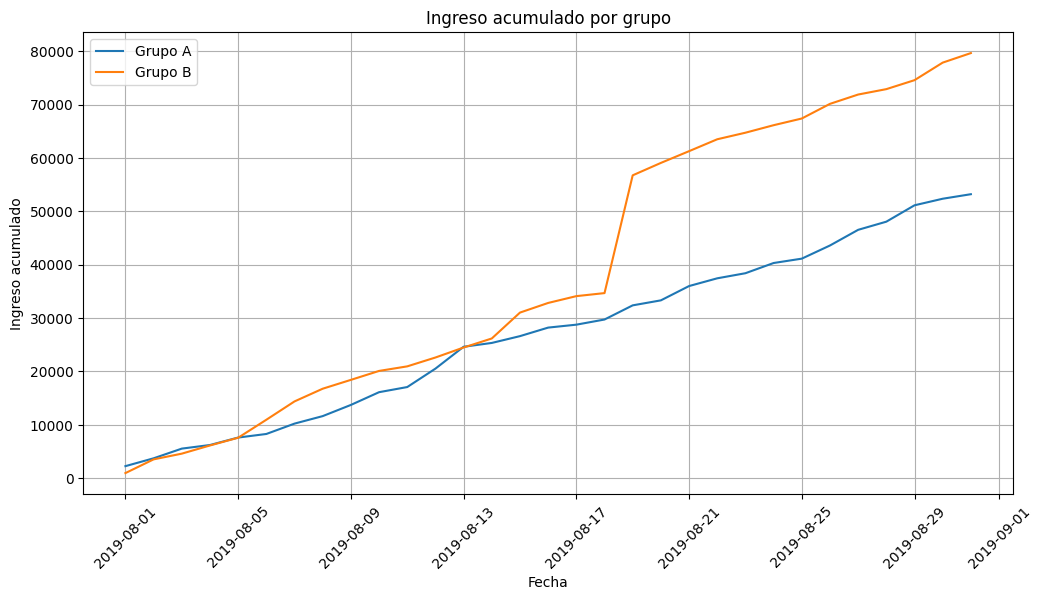

In [ ]:
plt.figure(figsize=(12, 6))

for group in daily_revenue['group'].unique():
    group_data = daily_revenue[daily_revenue['group'] == group]
    plt.plot(
        group_data['date'],
        group_data['cumulative_revenue'],
        label=f'Grupo {group}'
    )

plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Ingreso acumulado por grupo

Ambos grupos muestran una evolución creciente del ingreso acumulado durante el experimento.

El grupo B finaliza el periodo con un ingreso acumulado superior al grupo A. Sin embargo, alrededor del 19 de agosto presenta un incremento muy pronunciado que altera claramente su trayectoria.

Este comportamiento sugiere la posible presencia de uno o varios pedidos de valor excepcionalmente alto. Por ello, no es recomendable concluir todavía que el grupo B genera mayores ingresos de forma consistente; será necesario analizar los valores atípicos antes de tomar una decisión.

In [ ]:
# Pedidos e ingresos diarios por grupo
daily_orders = (
    orders_clean
    .groupby(['date', 'group'])
    .agg(
        orders=('transaction_id', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# Crear tabla por fecha y grupo
cumulative_orders = (
    daily_orders
    .pivot(
        index='date',
        columns='group',
        values=['orders', 'revenue']
    )
    .fillna(0)
)

cumulative_orders.columns = [
    'orders_a',
    'orders_b',
    'revenue_a',
    'revenue_b'
]

cumulative_orders = cumulative_orders.reset_index()

# Valores acumulados
cumulative_orders['cumulative_orders_a'] = cumulative_orders['orders_a'].cumsum()
cumulative_orders['cumulative_orders_b'] = cumulative_orders['orders_b'].cumsum()

cumulative_orders['cumulative_revenue_a'] = cumulative_orders['revenue_a'].cumsum()
cumulative_orders['cumulative_revenue_b'] = cumulative_orders['revenue_b'].cumsum()

# Tamaño promedio de pedido acumulado
cumulative_orders['cumulative_avg_order_a'] = (
    cumulative_orders['cumulative_revenue_a']
    / cumulative_orders['cumulative_orders_a']
)

cumulative_orders['cumulative_avg_order_b'] = (
    cumulative_orders['cumulative_revenue_b']
    / cumulative_orders['cumulative_orders_b']
)

cumulative_orders.head()

,date,orders_a,orders_b,revenue_a,revenue_b,cumulative_orders_a,cumulative_orders_b,cumulative_revenue_a,cumulative_revenue_b,cumulative_avg_order_a,cumulative_avg_order_b
0,2019-08-01,23.0,17.0,2266.6,967.2,23.0,17.0,2266.6,967.2,98.547826,56.894118
1,2019-08-02,19.0,23.0,1468.3,2568.1,42.0,40.0,3734.9,3535.3,88.926190,88.382500
2,2019-08-03,24.0,14.0,1815.2,1071.6,66.0,54.0,5550.1,4606.9,84.092424,85.312963
3,2019-08-04,11.0,14.0,675.5,1531.6,77.0,68.0,6225.6,6138.5,80.851948,90.272059
4,2019-08-05,22.0,21.0,1398.0,1449.3,99.0,89.0,7623.6,7587.8,77.006061,85.256180


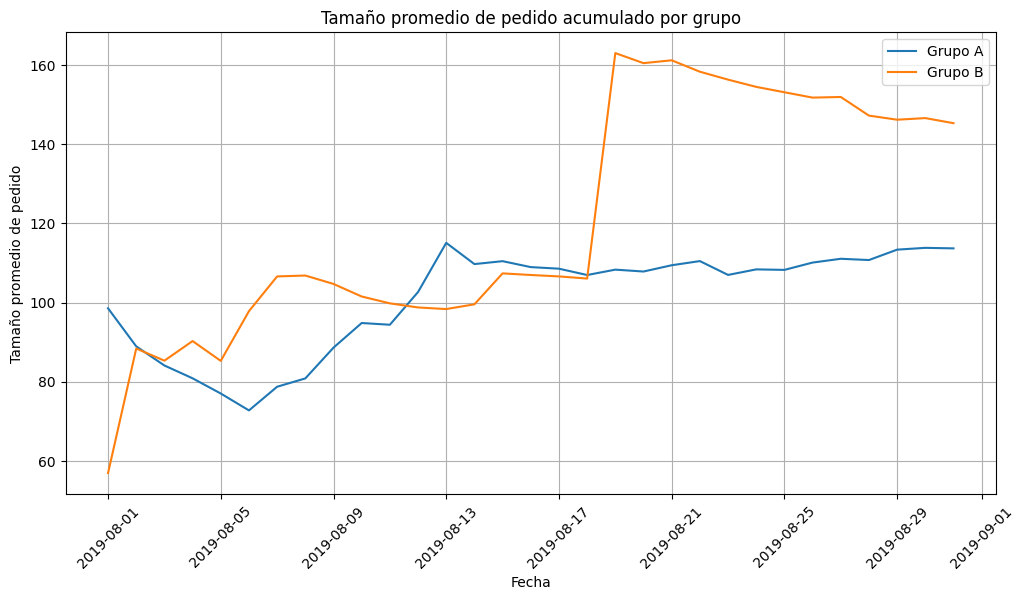

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_orders['date'],
    cumulative_orders['cumulative_avg_order_a'],
    label='Grupo A'
)

plt.plot(
    cumulative_orders['date'],
    cumulative_orders['cumulative_avg_order_b'],
    label='Grupo B'
)

plt.title('Tamaño promedio de pedido acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio de pedido')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Tamaño promedio de pedido acumulado

El grupo B alcanza un tamaño promedio de pedido acumulado superior al grupo A durante buena parte del experimento.

Sin embargo, alrededor del 19 de agosto se observa un incremento muy pronunciado en el grupo B. Este comportamiento sugiere que el promedio puede estar siendo distorsionado por uno o varios pedidos de valor atípicamente alto.

Por tanto, todavía no puede concluirse que el grupo B tenga un mejor desempeño real en esta métrica. Será necesario identificar y analizar los valores atípicos antes de tomar una decisión.

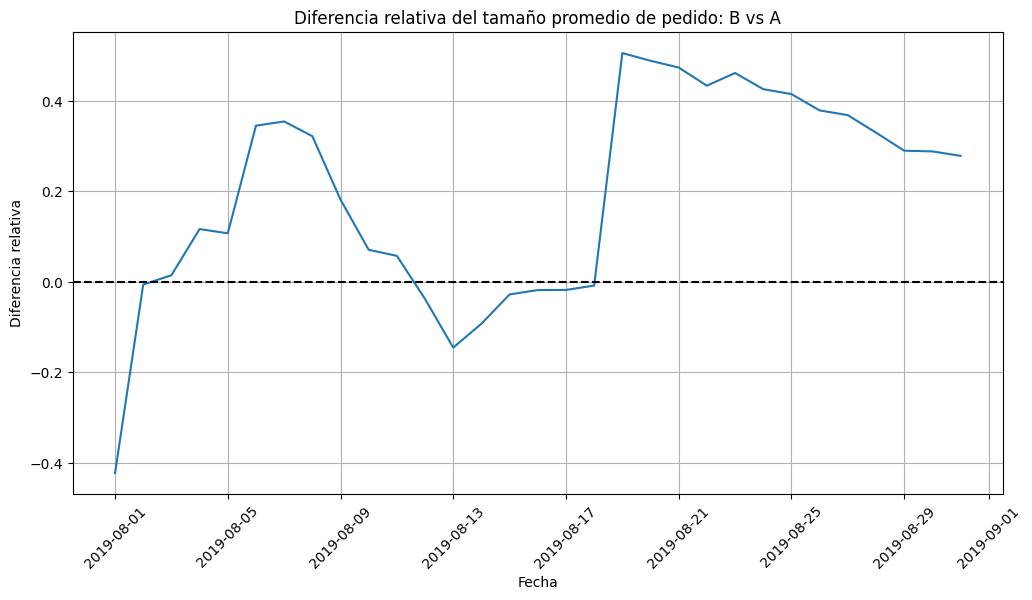

In [ ]:
cumulative_orders['relative_avg_order_b_vs_a'] = (
    cumulative_orders['cumulative_avg_order_b']
    / cumulative_orders['cumulative_avg_order_a']
    - 1
)

plt.figure(figsize=(12, 6))

plt.plot(
    cumulative_orders['date'],
    cumulative_orders['relative_avg_order_b_vs_a']
)

plt.axhline(y=0, color='black', linestyle='--')

plt.title('Diferencia relativa del tamaño promedio de pedido: B vs A')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Diferencia relativa del tamaño promedio de pedido

La diferencia relativa entre los grupos muestra que el grupo B se mantiene por encima del grupo A durante buena parte del experimento.

Sin embargo, la evolución presenta cambios bruscos, especialmente alrededor del 19 de agosto, lo que refuerza la hipótesis de que algunos pedidos de valor muy alto están influyendo de forma importante en esta métrica.

Por ello, la diferencia observada debe interpretarse con cautela hasta analizar los valores atípicos y repetir la comparación con datos filtrados.

In [ ]:
# Pedidos diarios por grupo
daily_orders_by_group = (
    orders_clean
    .groupby(['date', 'group'])
    .agg(orders=('transaction_id', 'nunique'))
    .reset_index()
)

# Combinar con visitas
daily_conversion = visits.merge(
    daily_orders_by_group,
    on=['date', 'group'],
    how='left'
)

daily_conversion['orders'] = daily_conversion['orders'].fillna(0)

daily_conversion['conversion'] = (
    daily_conversion['orders']
    / daily_conversion['visits']
)

conversion_pivot = (
    daily_conversion
    .pivot(
        index='date',
        columns='group',
        values='conversion'
    )
    .reset_index()
    .rename(columns={
        'A': 'conversion_a',
        'B': 'conversion_b'
    })
)

conversion_pivot.head()

group,date,conversion_a,conversion_b
0,2019-08-01,0.031989,0.023843
1,2019-08-02,0.030695,0.039587
2,2019-08-03,0.047337,0.027505
3,2019-08-04,0.015342,0.018182
4,2019-08-05,0.029101,0.029703


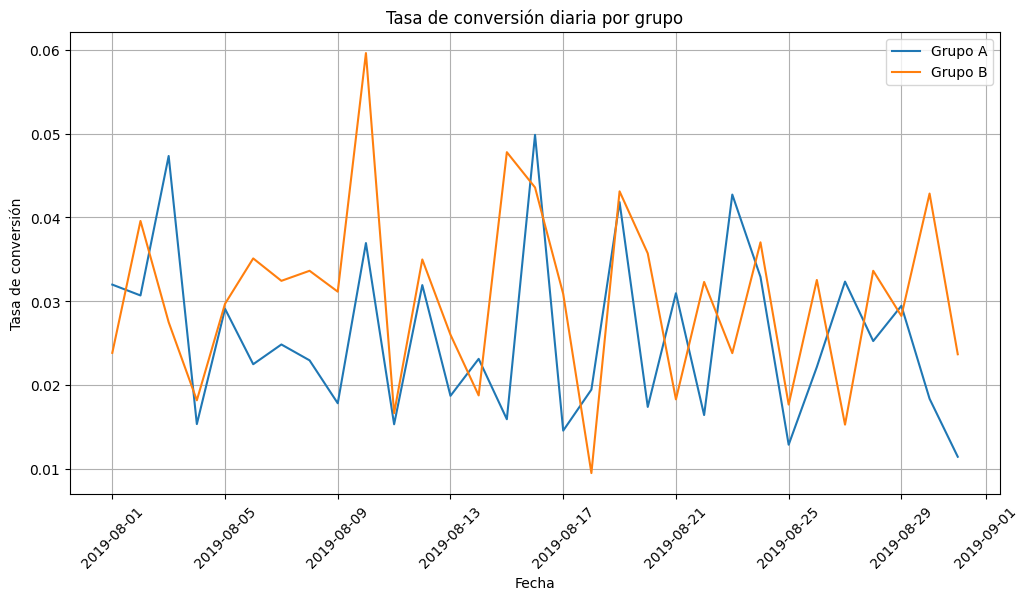

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    conversion_pivot['date'],
    conversion_pivot['conversion_a'],
    label='Grupo A'
)

plt.plot(
    conversion_pivot['date'],
    conversion_pivot['conversion_b'],
    label='Grupo B'
)

plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### Tasa de conversión diaria

La conversión presenta fluctuaciones importantes en ambos grupos a lo largo del experimento, algo esperable al analizar una métrica diaria sensible al volumen de visitas y pedidos.

Aunque el grupo B supera al grupo A en distintos momentos del periodo, la variabilidad de las tasas diarias impide concluir únicamente a partir del gráfico que una variante sea superior.

Por ello, la decisión final se apoyará en pruebas estadísticas y en una revisión de posibles valores atípicos.

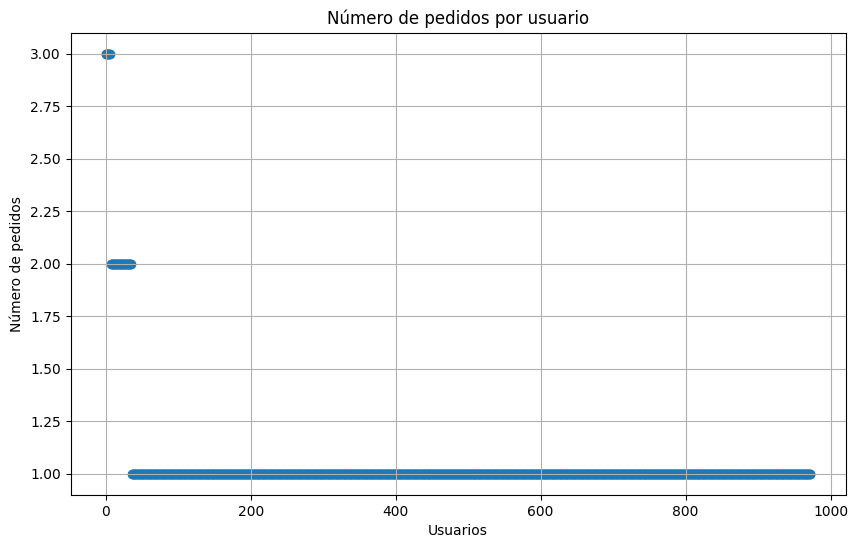

In [ ]:
# Número de pedidos por usuario
orders_per_user = (
    orders_clean
    .groupby('visitor_id')
    .agg(number_of_orders=('transaction_id', 'nunique'))
    .reset_index()
    .sort_values('number_of_orders', ascending=False)
)

x_values = pd.Series(range(len(orders_per_user)))

plt.figure(figsize=(10, 6))

plt.scatter(
    x_values,
    orders_per_user['number_of_orders']
)

plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()

### Pedidos por usuario

La distribución muestra que la mayoría de los usuarios realizó un único pedido durante el experimento.

Los usuarios con dos o más pedidos son mucho menos frecuentes, por lo que es necesario calcular los percentiles 95 y 99 para establecer un criterio objetivo de detección de valores atípicos.

In [ ]:
order_percentiles = (
    orders_per_user['number_of_orders']
    .quantile([0.95, 0.99])
)

order_percentiles

,number_of_orders
0.95,1.0
0.99,2.0


In [ ]:
print('Percentil 95:', order_percentiles.loc[0.95])
print('Percentil 99:', order_percentiles.loc[0.99])

Percentil 95: 1.0
Percentil 99: 2.0


### Umbral de anomalías por número de pedidos

El percentil 95 indica que el 95% de los usuarios realizó como máximo 1 pedido, mientras que el percentil 99 muestra que el 99% realizó como máximo 2 pedidos.

Por ello, se considerarán anómalos los usuarios con **más de 2 pedidos**, ya que representan menos del 1% de la muestra y podrían distorsionar el análisis.

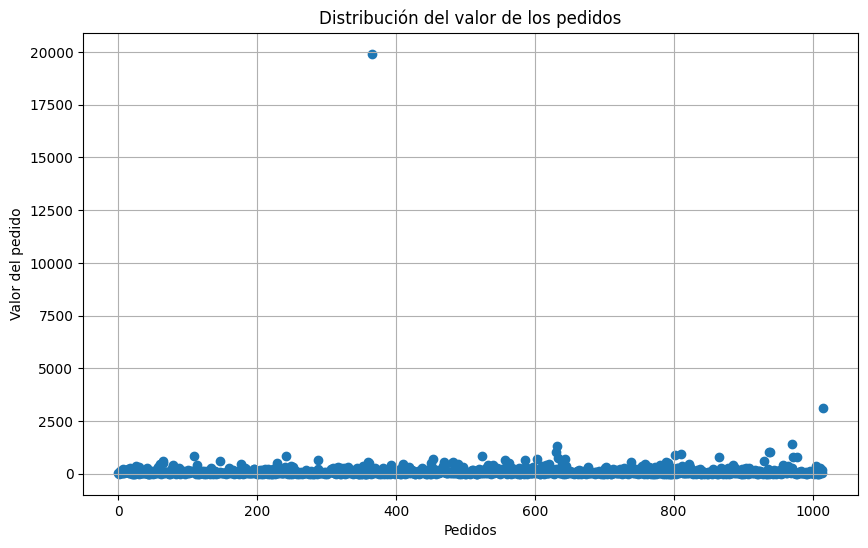

In [ ]:
x_values = pd.Series(range(len(orders_clean)))

plt.figure(figsize=(10, 6))

plt.scatter(
    x_values,
    orders_clean['revenue']
)

plt.title('Distribución del valor de los pedidos')
plt.xlabel('Pedidos')
plt.ylabel('Valor del pedido')
plt.grid(True)
plt.show()

In [ ]:
orders_clean[
    ['transaction_id', 'visitor_id', 'date', 'revenue', 'group']
].sort_values(
    'revenue',
    ascending=False
).head(10)

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,19920.4,B
1196,3936777065,2108080724,2019-08-15,3120.1,B
1136,666610489,1307669133,2019-08-13,1425.8,A
744,3668308183,888512513,2019-08-27,1335.6,B
743,3603576309,4133034833,2019-08-09,1050.0,A
1103,1348774318,1164614297,2019-08-12,1025.8,A
1099,316924019,148427295,2019-08-12,1015.9,A
949,1347999392,887908475,2019-08-21,930.0,A
940,2420050534,4003628586,2019-08-08,905.8,B
131,3163614039,2254586615,2019-08-22,830.3,A


### Valores de los pedidos

La mayoría de los pedidos presenta importes relativamente bajos o moderados. Sin embargo, se observan algunos valores claramente alejados del resto.

Destaca especialmente un pedido de 19,920.4 en el grupo B, cuyo importe es muy superior al resto de las transacciones. Este valor puede distorsionar significativamente métricas como el tamaño promedio de pedido.

Para establecer un umbral objetivo de anomalías, se calcularán los percentiles 95 y 99 del valor de los pedidos.

In [ ]:
revenue_percentiles = orders_clean['revenue'].quantile([0.95, 0.99])

print('Percentil 95:', revenue_percentiles.loc[0.95])
print('Percentil 99:', revenue_percentiles.loc[0.99])

Percentil 95: 414.275
Percentil 99: 830.3


### Umbral de anomalías por valor de pedido

El 95% de los pedidos tiene un valor de hasta 414.28, mientras que el 99% se sitúa por debajo de 830.30.

Por ello, se considerarán anómalos los pedidos con un valor superior a **830.30**, ya que representan menos del 1% de las transacciones y pueden distorsionar métricas como el tamaño promedio de pedido.

In [ ]:
# Pedidos por usuario en cada grupo
orders_by_user_a = (
    orders_clean[orders_clean['group'] == 'A']
    .groupby('visitor_id')
    .agg(number_of_orders=('transaction_id', 'nunique'))
    .reset_index()
)

orders_by_user_b = (
    orders_clean[orders_clean['group'] == 'B']
    .groupby('visitor_id')
    .agg(number_of_orders=('transaction_id', 'nunique'))
    .reset_index()
)

# Crear muestras incluyendo usuarios que visitaron pero no compraron
sample_a = pd.concat([
    orders_by_user_a['number_of_orders'],
    pd.Series(
        0,
        index=np.arange(
            visits[visits['group'] == 'A']['visits'].sum()
            - len(orders_by_user_a)
        )
    )
])

sample_b = pd.concat([
    orders_by_user_b['number_of_orders'],
    pd.Series(
        0,
        index=np.arange(
            visits[visits['group'] == 'B']['visits'].sum()
            - len(orders_by_user_b)
        )
    )
])

p_value_conversion = st.mannwhitneyu(sample_a, sample_b)[1]

relative_conversion_difference = (
    sample_b.mean() / sample_a.mean() - 1
)

print('p-value:', round(p_value_conversion, 5))
print(
    'Diferencia relativa de conversión B vs A:',
    round(relative_conversion_difference, 3)
)

p-value: 0.01102
Diferencia relativa de conversión B vs A: 0.16


### Conversión con datos en bruto

La prueba de Mann–Whitney muestra una diferencia estadísticamente significativa entre los grupos, con un p-value de 0.01102.

La conversión del grupo B es aproximadamente un 16% superior a la del grupo A.

Por tanto, con los datos en bruto existe evidencia de que la variante B mejora la conversión. Aun así, será necesario repetir el análisis después de eliminar los valores atípicos para comprobar si esta ventaja se mantiene.

In [ ]:
p_value_avg_order = st.mannwhitneyu(
    orders_clean[orders_clean['group'] == 'A']['revenue'],
    orders_clean[orders_clean['group'] == 'B']['revenue']
)[1]

relative_avg_order_difference = (
    orders_clean[orders_clean['group'] == 'B']['revenue'].mean()
    / orders_clean[orders_clean['group'] == 'A']['revenue'].mean()
    - 1
)

print('p-value:', round(p_value_avg_order, 5))
print(
    'Diferencia relativa del tamaño promedio de pedido B vs A:',
    round(relative_avg_order_difference, 3)
)

p-value: 0.86223
Diferencia relativa del tamaño promedio de pedido B vs A: 0.278


### Tamaño promedio de pedido con datos en bruto

El tamaño promedio de pedido del grupo B es aproximadamente un 27.8% superior al del grupo A.

Sin embargo, el p-value obtenido es 0.86223, muy superior al nivel de significancia de 0.05. Por tanto, no existe evidencia estadística suficiente para afirmar que ambos grupos difieran realmente en esta métrica.

La diferencia observada puede estar influida por valores atípicos, especialmente por los pedidos de importe excepcionalmente alto detectados anteriormente.

In [ ]:
# Usuarios con un número anómalo de pedidos
users_many_orders = orders_per_user[
    orders_per_user['number_of_orders'] > 2
]['visitor_id']

# Usuarios con pedidos de valor anómalo
users_expensive_orders = orders_clean[
    orders_clean['revenue'] > 830.30
]['visitor_id']

# Unificar ambos grupos de usuarios
anomalous_users = pd.concat([
    users_many_orders,
    users_expensive_orders
]).drop_duplicates()

print('Usuarios anómalos identificados:', len(anomalous_users))

Usuarios anómalos identificados: 16


In [ ]:
sample_a_filtered = pd.concat([
    orders_by_user_a[
        ~orders_by_user_a['visitor_id'].isin(anomalous_users)
    ]['number_of_orders'],
    pd.Series(
        0,
        index=np.arange(
            visits[visits['group'] == 'A']['visits'].sum()
            - len(orders_by_user_a)
        )
    )
])

sample_b_filtered = pd.concat([
    orders_by_user_b[
        ~orders_by_user_b['visitor_id'].isin(anomalous_users)
    ]['number_of_orders'],
    pd.Series(
        0,
        index=np.arange(
            visits[visits['group'] == 'B']['visits'].sum()
            - len(orders_by_user_b)
        )
    )
])

p_value_conversion_filtered = st.mannwhitneyu(
    sample_a_filtered,
    sample_b_filtered
)[1]

relative_conversion_filtered = (
    sample_b_filtered.mean()
    / sample_a_filtered.mean()
    - 1
)

print('p-value:', round(p_value_conversion_filtered, 5))
print(
    'Diferencia relativa de conversión B vs A:',
    round(relative_conversion_filtered, 3)
)

p-value: 0.00702
Diferencia relativa de conversión B vs A: 0.189


### Conversión con datos filtrados

Después de excluir los usuarios con comportamiento anómalo, la diferencia entre los grupos sigue siendo estadísticamente significativa.

El p-value obtenido es 0.00702, inferior a 0.05, y la conversión del grupo B es aproximadamente un 18.9% superior a la del grupo A.

Esto confirma que la mejora observada en la conversión del grupo B no depende de los valores atípicos y se mantiene después de limpiar los datos.

In [ ]:
# Eliminar usuarios anómalos del dataset de pedidos
orders_filtered = orders_clean[
    ~orders_clean['visitor_id'].isin(anomalous_users)
]

p_value_avg_order_filtered = st.mannwhitneyu(
    orders_filtered[orders_filtered['group'] == 'A']['revenue'],
    orders_filtered[orders_filtered['group'] == 'B']['revenue']
)[1]

relative_avg_order_filtered = (
    orders_filtered[orders_filtered['group'] == 'B']['revenue'].mean()
    / orders_filtered[orders_filtered['group'] == 'A']['revenue'].mean()
    - 1
)

print('p-value:', round(p_value_avg_order_filtered, 5))
print(
    'Diferencia relativa del tamaño promedio de pedido B vs A:',
    round(relative_avg_order_filtered, 3)
)

p-value: 0.82203
Diferencia relativa del tamaño promedio de pedido B vs A: -0.032


### Tamaño promedio de pedido con datos filtrados

Después de eliminar los usuarios y pedidos anómalos, no se observa una diferencia estadísticamente significativa en el tamaño promedio de pedido entre los grupos.

El p-value obtenido es 0.82203, superior a 0.05, mientras que el tamaño promedio de pedido del grupo B resulta aproximadamente un 3.2% inferior al del grupo A.

Esto confirma que la ventaja inicial observada en el grupo B estaba influida por valores atípicos y no representa una mejora real en esta métrica.

## Conclusión y decisión de negocio

Los resultados del experimento muestran dos comportamientos diferentes según la métrica analizada.

### Conversión

El grupo B obtiene una mejora estadísticamente significativa:

- **+16% de conversión** con los datos en bruto.
- **+18.9% de conversión** después de eliminar valores atípicos.
- En ambos análisis, el p-value es inferior a 0.05.

Esto indica que la mejora en conversión es consistente y no depende de comportamientos anómalos.

### Tamaño promedio de pedido

No se encontraron diferencias estadísticamente significativas entre los grupos.

La aparente ventaja inicial del grupo B desaparece al eliminar valores atípicos, pasando de +27.8% a aproximadamente -3.2%.

### Decisión

**Se recomienda detener el experimento y considerar al grupo B como la variante ganadora.**

Aunque B no genera pedidos de mayor valor, sí consigue convertir una proporción significativamente mayor de visitantes en compradores.

Desde una perspectiva de negocio, la variante B representa una mejora en la capacidad de conversión del e-commerce y puede considerarse para su implementación.

--------------------------------------------------------------------------------

In [ ]:
import os

os.makedirs('/content/images', exist_ok=True)

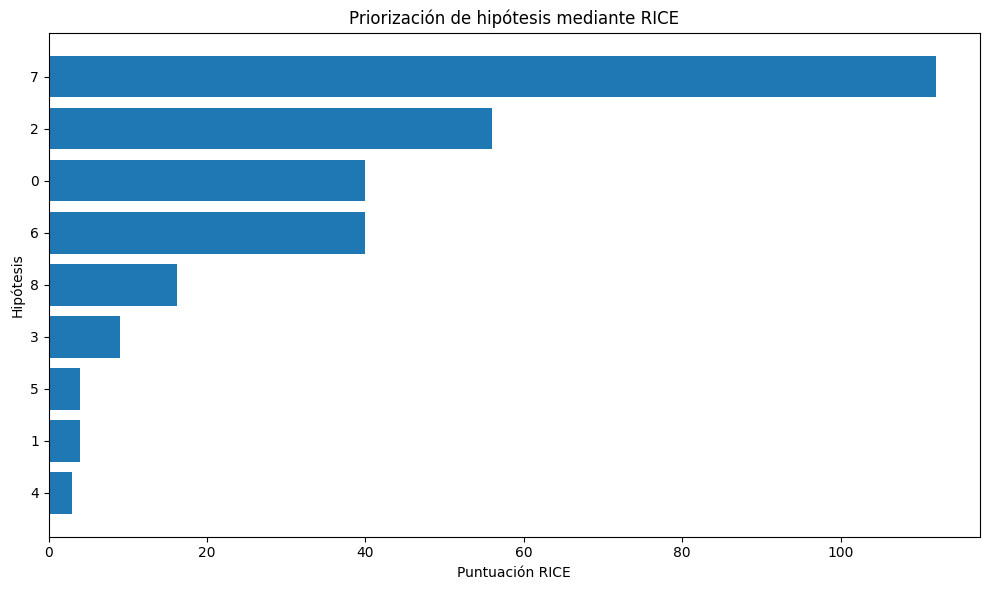

In [ ]:
# Visual 1: Priorización de hipótesis mediante RICE

rice_visual = (
    hypotheses
    .sort_values('rice', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    rice_visual.index.astype(str),
    rice_visual['rice']
)

plt.title('Priorización de hipótesis mediante RICE')
plt.xlabel('Puntuación RICE')
plt.ylabel('Hipótesis')

plt.tight_layout()

plt.savefig(
    '/content/images/rice_prioritization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

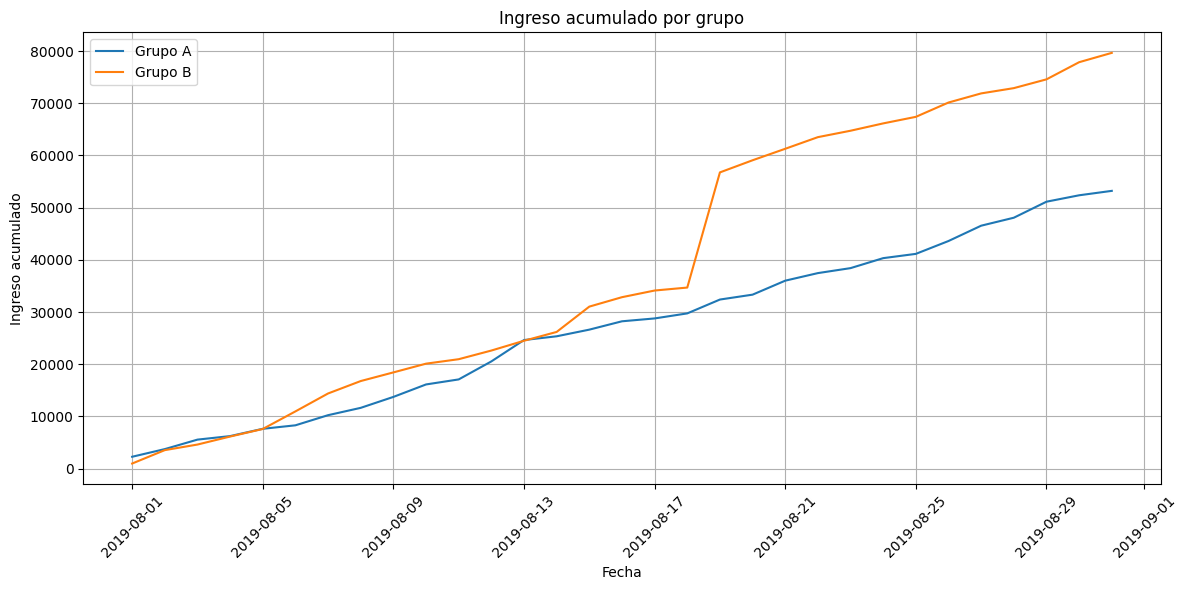

In [ ]:
# Visual 2: Ingreso acumulado por grupo

plt.figure(figsize=(12, 6))

for group in daily_revenue['group'].unique():
    group_data = daily_revenue[daily_revenue['group'] == group]

    plt.plot(
        group_data['date'],
        group_data['cumulative_revenue'],
        label=f'Grupo {group}'
    )

plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    '/content/images/cumulative_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

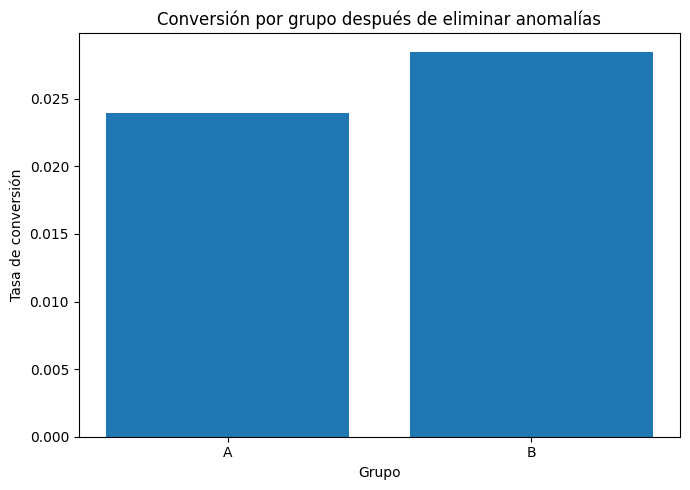

Mejora relativa de B vs A: 18.9%


In [ ]:
# Visual 3: Conversión final por grupo con datos filtrados

conversion_a_filtered = sample_a_filtered.mean()
conversion_b_filtered = sample_b_filtered.mean()

conversion_results = pd.DataFrame({
    'group': ['A', 'B'],
    'conversion': [
        conversion_a_filtered,
        conversion_b_filtered
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    conversion_results['group'],
    conversion_results['conversion']
)

plt.title('Conversión por grupo después de eliminar anomalías')
plt.xlabel('Grupo')
plt.ylabel('Tasa de conversión')

plt.tight_layout()

plt.savefig(
    '/content/images/filtered_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    'Mejora relativa de B vs A:',
    f'{relative_conversion_filtered:.1%}'
)